# 1. Bibliotecas Usadas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import learning_curve
from imblearn.under_sampling import RandomUnderSampler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 2. Carregamento dos Dados

In [ ]:
# Configurações de visualização
plt.style.use('ggplot')
sns.set_palette("viridis")

# 1. Carregamento dos dados
path = "/content/drive/MyDrive/Geman Credit Risk/Silver/german_credit_data_with_target.csv"
df = pd.read_csv(path, index_col=0)


#3. Estrutura dos Dados

In [ ]:
# Inspeção Inicial
print(f"Dimensões do Dataset: {df.shape}")
df.head()

Dimensões do Dataset: (1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


# 4. Análise Exploratória de Dados (EDA)

### 4.1.1 Auditoria de Metadados e Cardinalidade

In [ ]:
# Criando um dicionário de metadados
meta_data = []
for col in df.columns:
    meta_data.append({
        'Variável': col,
        'Tipo': df[col].dtype,
        'Nulos': df[col].isnull().sum(),
        'Nulos (%)': (df[col].isnull().sum() / len(df)) * 100,
        'Valores Únicos': df[col].nunique()
    })

meta_df = pd.DataFrame(meta_data)
display(meta_df)

,Variável,Tipo,Nulos,Nulos (%),Valores Únicos
0,Age,int64,0,0.0,53
1,Sex,object,0,0.0,2
2,Job,int64,0,0.0,4
3,Housing,object,0,0.0,3
4,Saving accounts,object,0,0.0,5
5,Checking account,object,0,0.0,4
6,Credit amount,int64,0,0.0,921
7,Duration,int64,0,0.0,33
8,Purpose,object,0,0.0,8
9,Risk,int64,0,0.0,2


### 4.4.2 Análise de Perfil e Comportamento (Visual EDA)
Nesta etapa, vamos entender a demografia e os hábitos financeiros da base de clientes.

/tmp/ipython-input-1187899318.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=housing_pct.index, y=housing_pct.values, ax=axes[0, 1], palette='viridis')
/tmp/ipython-input-1187899318.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Saving accounts', data=df.fillna('Não Informado'), ax=axes[1, 0], palette='magma', order=df.fillna('Não Informado')['Saving accounts'].value_counts().index)
/tmp/ipython-input-1187899318.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=duration_mean.values, y=duration_mean.index, ax=axes[2, 0

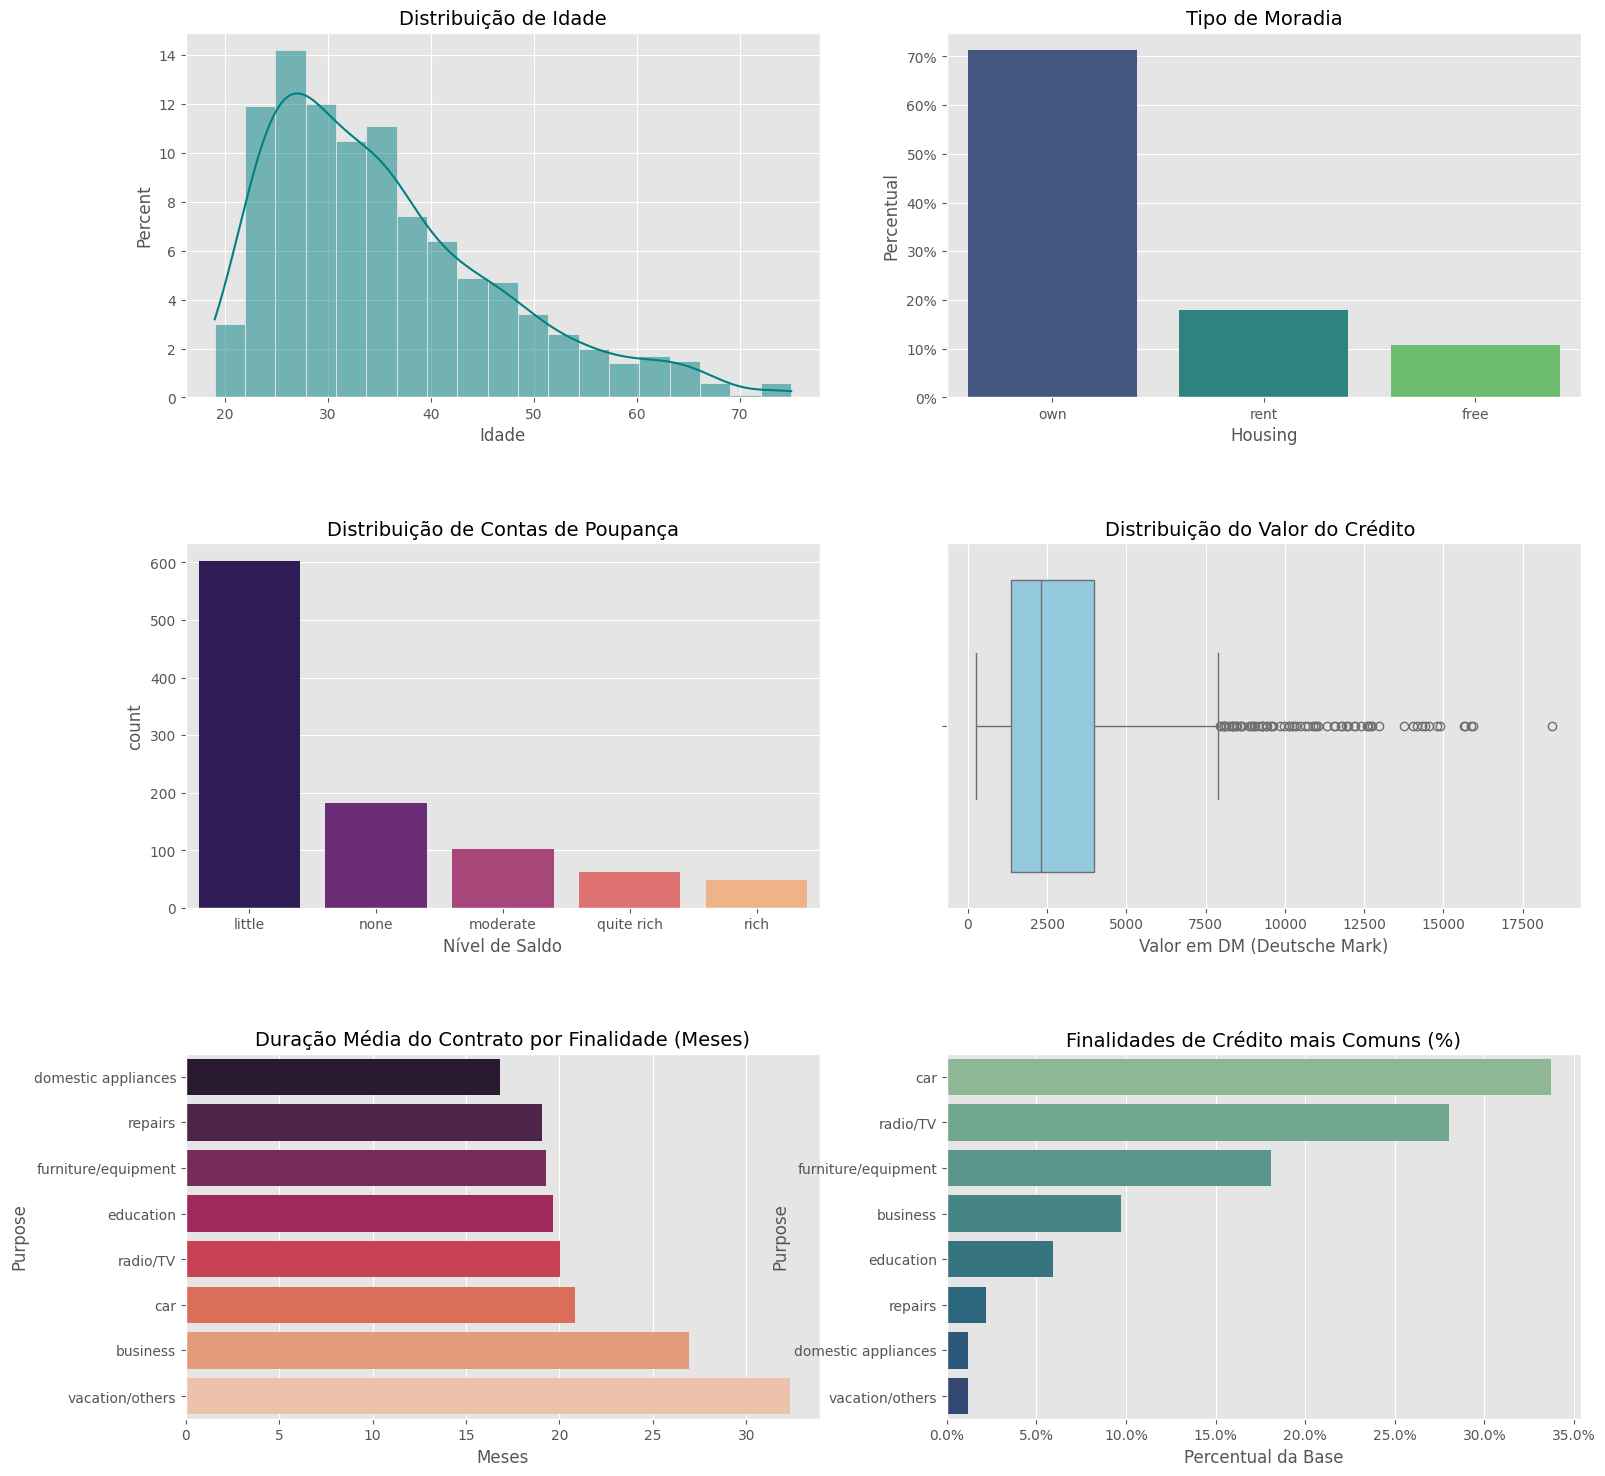

In [ ]:
# Configurando o layout para múltiplos gráficos
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
plt.subplots_adjust(hspace=0.4)

# 1. Distribuição de Idade por % (Histograma com KDE)
sns.histplot(df['Age'], kde=True, ax=axes[0, 0], color='teal', stat="percent")
axes[0, 0].set_title('Distribuição de Idade', fontsize=14)
axes[0, 0].set_xlabel('Idade')

# 2. Tipo de Moradia (Housing) - Gráfico de Barras com %
housing_pct = df['Housing'].value_counts(normalize=True) * 100
sns.barplot(x=housing_pct.index, y=housing_pct.values, ax=axes[0, 1], palette='viridis')
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0, 1].set_title('Tipo de Moradia', fontsize=14)
axes[0, 1].set_ylabel('Percentual')

# 3. Saving Accounts - Impacto da Reserva Financeira
# Tratando nulos momentaneamente para visualização
sns.countplot(x='Saving accounts', data=df.fillna('Não Informado'), ax=axes[1, 0], palette='magma', order=df.fillna('Não Informado')['Saving accounts'].value_counts().index)
axes[1, 0].set_title('Distribuição de Contas de Poupança', fontsize=14)
axes[1, 0].set_xlabel('Nível de Saldo')

# 4. Credit Amount - Boxplot para identificar Outliers
sns.boxplot(x='Credit amount', data=df, ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('Distribuição do Valor do Crédito ', fontsize=14)
axes[1, 1].set_xlabel('Valor em DM (Deutsche Mark)')

# 5. Duração dos Créditos em Média por Finalidade
duration_mean = df.groupby('Purpose')['Duration'].mean().sort_values()
sns.barplot(x=duration_mean.values, y=duration_mean.index, ax=axes[2, 0], palette='rocket')
axes[2, 0].set_title('Duração Média do Contrato por Finalidade (Meses)', fontsize=14)
axes[2, 0].set_xlabel('Meses')

# 6. Finalidade mais comum (Volume de Contratos)
purpose_counts = df['Purpose'].value_counts(normalize=True) * 100
sns.barplot(x=purpose_counts.values, y=purpose_counts.index, ax=axes[2, 1], palette='crest')
axes[2, 1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[2, 1].set_title('Finalidades de Crédito mais Comuns (%)', fontsize=14)
axes[2, 1].set_xlabel('Percentual da Base')

plt.show()

### 4.4.4 Variáveis Numéricas vs Target (Poder de Separação)
Vamos utilizar visualizações que combinam a distribuição estatística (Boxplot) e a densidade (KDE) para entender onde o risco se concentra.
0 = Mau Pagador
1 = Bom Pagador

/tmp/ipython-input-1021356298.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, ax=axes[i], palette='Set2')
/tmp/ipython-input-1021356298.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, ax=axes[i], palette='Set2')
/tmp/ipython-input-1021356298.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk', y=col, ax=axes[i], palette='Set2')


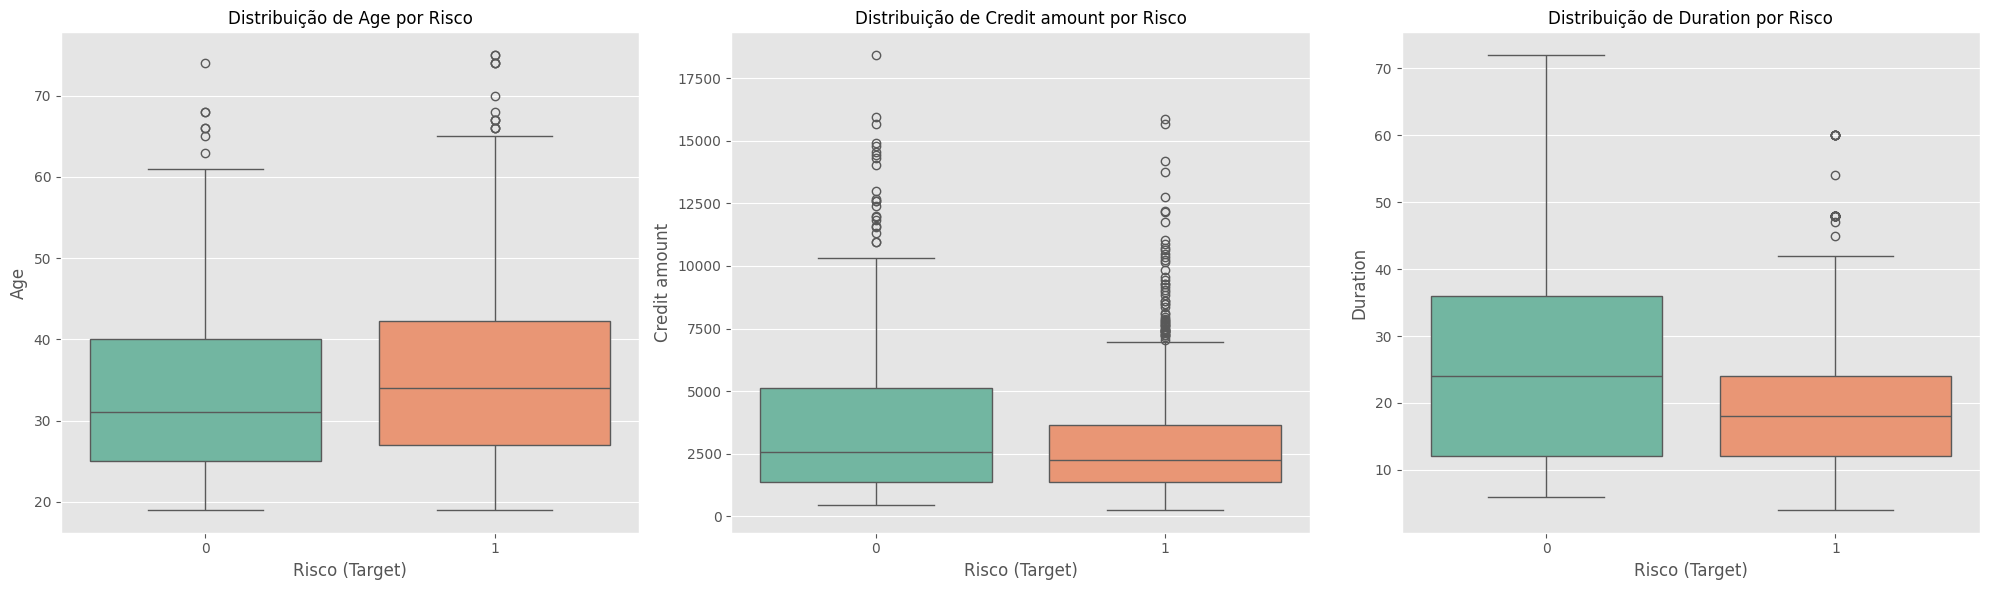

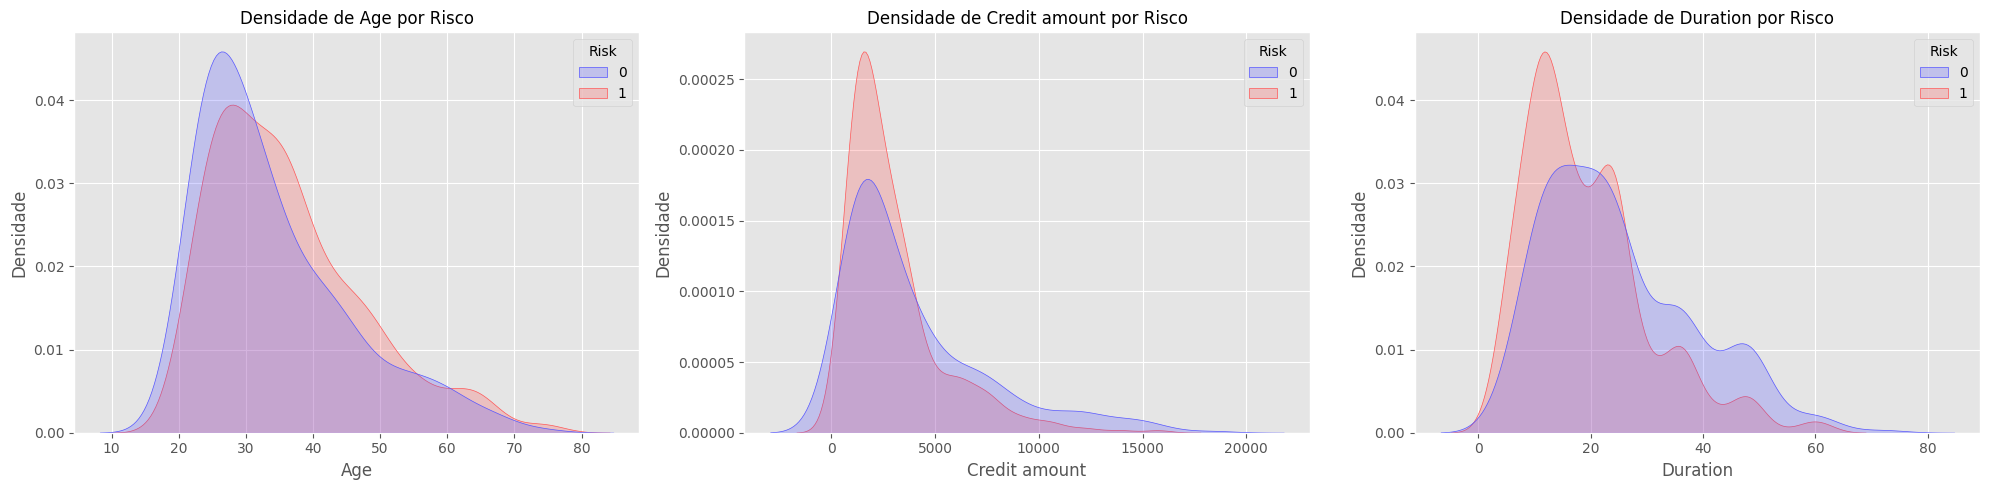

In [ ]:
# Definindo as variáveis numéricas
num_features = ['Age', 'Credit amount', 'Duration']

# Criando a figura
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(num_features):
    # Gráfico de Boxplot para ver medianas e quartis por classe de risco
    sns.boxplot(data=df, x='Risk', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribuição de {col} por Risco', fontsize=12)
    axes[i].set_xlabel('Risco (Target)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Análise de Densidade (KDE) para sobreposição de classes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

for i, col in enumerate(num_features):
    sns.kdeplot(data=df, x=col, hue='Risk', fill=True, common_norm=False, ax=axes[i], palette='seismic')
    axes[i].set_title(f'Densidade de {col} por Risco', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidade')

plt.tight_layout()
plt.show()

In [ ]:
# Médias das variáveis numéricas agrupadas pelo risco
print("Média das variáveis por categoria de risco:")
display(df.groupby('Risk')[num_features].mean())

# Mediana das variáveis por categoria de risco (menos sensível a outliers)
print("\nMediana das variáveis por categoria de risco:")
display(df.groupby('Risk')[num_features].median())

Média das variáveis por categoria de risco:


,Age,Credit amount,Duration
Risk,,,
0,33.963333,3938.126667,24.860000
1,36.224286,2985.457143,19.207143



Mediana das variáveis por categoria de risco:


,Age,Credit amount,Duration
Risk,,,
0,31.0,2574.5,24.0
1,34.0,2244.0,18.0


### 4.4.5 Visualização de Multicolinearidade
Nesta etapa, analisamos como as variáveis numéricas se relacionam entre si. Em modelos de crédito, é vital evitar a multicolinearidade.

Se duas variáveis forem extremamente correlacionadas, elas carregam a mesma informação. Isso pode inflar a variância dos coeficientes em modelos lineares (como a Regressão Logística) e tornar o modelo instável.

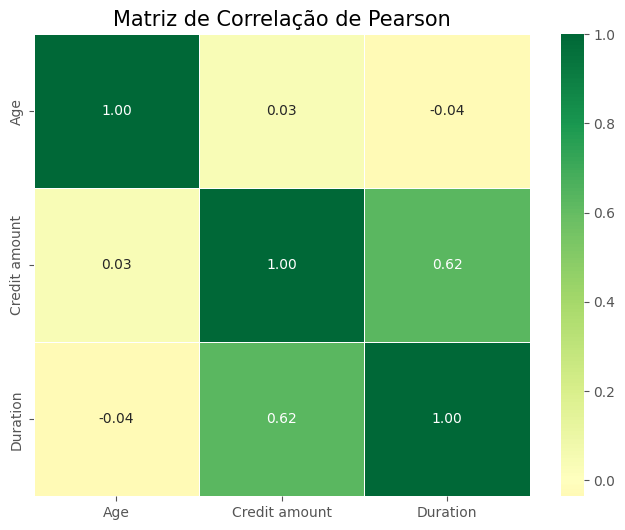

In [ ]:
# Seleção de variáveis numéricas
num_features = ['Age', 'Credit amount', 'Duration']

# Cálculo da correlação
corr_matrix = df[num_features].corr()

# Visualização com Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação de Pearson', fontsize=15)
plt.show()

# 5. Preparação dos Dados

## 5.1 Tratamento de Valores Ausentes e Engenharia de Atributos
Em vez de imputar a média ou moda, trataremos os nulos como uma categoria "Não Informado", preservando o sinal estatístico identificado na EDA.

In [ ]:
# Criando cópia de segurança
df_prep = df.copy()

# 1. Tratamento de Variáveis Explicativas (X)
# Mantemos a ausência de informação como categoria para preservar o sinal de risco
df_prep['Saving accounts'] = df_prep['Saving accounts'].fillna('unavailable')
df_prep['Checking account'] = df_prep['Checking account'].fillna('unavailable')

# 2. Garantia de Integridade do Target (y)
# Como identificado anteriormente, o target já é numérico [0, 1]
df_prep['Risk'] = df_prep['Risk'].astype(int)

print(f"Check de Nulos Final:\n{df_prep.isnull().sum()}")

Check de Nulos Final:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


### 5.2 Encoding de Variáveis Categóricas

Utilizaremos o One-Hot Encoding. Para o modelo, usamos drop_first=True para evitar a armadilha da multicolinearidade (Dummy Variable Trap).

In [ ]:
# Seleção de colunas categóricas
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

# Transformação em variáveis binárias (Dummies)
df_final = pd.get_dummies(df_prep, columns=cat_cols, drop_first=True)

print(f"Dimensões após Encoding: {df_final.shape}")

Dimensões após Encoding: (1000, 22)


### 5.3 Divisão entre Treino e Teste (Split)

A divisão 70/30 com estratificação garante que a proporção de inadimplentes (Target 0) seja a mesma em ambos os conjuntos, evitando viés de avaliação.

In [ ]:
# Separação
X = df_final.drop('Risk', axis=1)
y = df_final['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Base de Treino: {X_train.shape[0]} amostras")
print(f"Base de Teste: {X_test.shape[0]} amostras")

Base de Treino: 700 amostras
Base de Teste: 300 amostras


### 5.4 Escalonamento (Feature Scaling)

In [ ]:
scaler = StandardScaler()
num_cols = ['Age', 'Credit amount', 'Duration']

# O scaler é 'ajustado' apenas no treino para evitar data leakage
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

#6. Modelagem Preditiva
Nesta etapa, comparamos duas abordagens distintas: a Regressão Logística, que atua como nosso baseline devido à sua transparência, e os modelos de arvore, que lidam melhor com as relações não-lineares identificadas na nossa EDA.

### 6.1 Diagnóstico Estatístico de Regressão Logística

In [ ]:
# Adicionando a constante (intercepto) e preparando os dados
X_train_stat = sm.add_constant(X_train)

# Conversão de booleanos para int (exigência do statsmodels)
for col in X_train_stat.select_dtypes(include=['bool']).columns:
    X_train_stat[col] = X_train_stat[col].astype(int)

# Ajuste e sumário do modelo logístico
logit_model = sm.Logit(y_train, X_train_stat).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.500656
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   Risk   No. Observations:                  700
Model:                          Logit   Df Residuals:                      678
Method:                           MLE   Df Model:                           21
Date:                Tue, 03 Feb 2026   Pseudo R-squ.:                  0.1804
Time:                        19:36:36   Log-Likelihood:                -350.46
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 2.675e-22
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.7726      0.576     -1.341      0.180   

Variáveis com $P > |z| > 0.05$ (como Job e certas categorias de Purpose) indicam baixa significância estatística individual no modelo logístico.

### 6.2 Diagnóstico de Resíduos

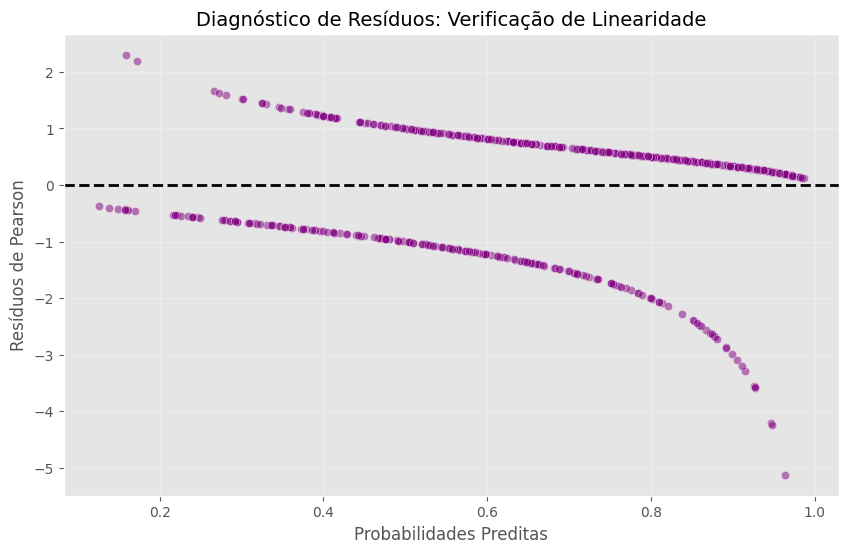

In [ ]:
# Garantindo que o modelo está ajustado
X_train_stat = sm.add_constant(X_train)
for col in X_train_stat.select_dtypes(include=['bool']).columns:
    X_train_stat[col] = X_train_stat[col].astype(int)
result = sm.Logit(y_train, X_train_stat).fit(disp=0)

# Cálculo dos Resíduos e Probabilidades
residuos = result.resid_pearson
probabilidades = result.predict()

# Gráfico de Resíduos vs Probabilidades
plt.figure(figsize=(10, 6))
sns.scatterplot(x=probabilidades, y=residuos, alpha=0.5, color='purple')
plt.axhline(y=0, color='black', linestyle='--', lw=2)

plt.title('Diagnóstico de Resíduos: Verificação de Linearidade', fontsize=14)
plt.xlabel('Probabilidades Preditas')
plt.ylabel('Resíduos de Pearson')
plt.grid(True, alpha=0.3)
plt.show()

# 7.1 Modelagem: Comparativo de Performance

In [ ]:
# 1. Definição dos modelos (parâmetros preservados)
models = {
    "LogisticRegression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, scale_pos_weight=2.3, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=300, learning_rate=0.05, class_weight='balanced', random_state=42, verbosity=-1)
}

# 2. Loop de Auditoria (Treino 5-Folds e Teste)
results_audit = []

for name, model in models.items():
    # --- FASE 1: Treino com 5-Fold Cross Validation ---
    start_time_cv = time.time()
    cv_results = cross_validate(model, X_train, y_train, cv=5,
                                 scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
    total_time_cv = time.time() - start_time_cv

    results_audit.append({
        "model": name, "approach": "Treino 5 K-folds",
        "acc": cv_results['test_accuracy'].mean(),
        "precision": cv_results['test_precision'].mean(),
        "recall": cv_results['test_recall'].mean(),
        "f1": cv_results['test_f1'].mean(),
        "auc": cv_results['test_roc_auc'].mean(),
        "total_time": total_time_cv
    })

    # --- FASE 2: Teste Final (Hold-out) ---
    start_time_test = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    total_time_test = time.time() - start_time_test

    report = classification_report(y_test, y_pred, output_dict=True)

    results_audit.append({
        "model": name, "approach": "Teste",
        "acc": report['accuracy'],
        "precision": report['0']['precision'],
        "recall": report['0']['recall'],
        "f1": report['0']['f1-score'],
        "auc": roc_auc_score(y_test, y_prob),
        "total_time": total_time_test
    })

# 3. Formatação da Tabela de Auditoria
df_audit = pd.DataFrame(results_audit)

styled_audit = df_audit.style.background_gradient(cmap='Blues', subset=['acc', 'precision', 'recall', 'f1', 'auc'])\
    .format({'acc': '{:.4f}', 'precision': '{:.4f}', 'recall': '{:.4f}', 'f1': '{:.4f}', 'auc': '{:.4f}', 'total_time': '{:.3f}'})\
    .set_caption("Tabela de Auditoria: Treino (K-Folds) vs Teste Final")\
    .set_properties(**{'text-align': 'center', 'border': '1px solid #ddd'})

display(styled_audit)

,model,approach,acc,precision,recall,f1,auc,total_time
0,LogisticRegression,Treino 5 K-folds,0.6900,0.8454,0.6816,0.7536,0.7486,1.355
1,LogisticRegression,Teste,0.6867,0.4853,0.7333,0.5841,0.7551,0.199
2,RandomForest,Treino 5 K-folds,0.7300,0.7917,0.8347,0.8117,0.7554,6.818
3,RandomForest,Teste,0.7367,0.5679,0.5111,0.5380,0.7506,1.120
4,XGBoost,Treino 5 K-folds,0.7386,0.7722,0.8898,0.8264,0.7500,3.873
5,XGBoost,Teste,0.7500,0.6531,0.3556,0.4604,0.7346,0.517
6,LightGBM,Treino 5 K-folds,0.7086,0.7990,0.7796,0.7887,0.7412,1.131
7,LightGBM,Teste,0.7100,0.5172,0.5000,0.5085,0.7244,0.474


In [ ]:
# 1. Instanciando os modelos com foco em balanceamento
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight='balanced', random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=2.3, # Ajustado para o desbalanceamento 70/30
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced', random_state=42, verbosity=-1
    )
}

# 2. Loop de treinamento e avaliação
resumo_final = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, preds, output_dict=True)

    resumo_final.append({
        "Modelo": name,
        "ROC-AUC": roc_auc_score(y_test, probs),
        "Recall (Classe 0)": report['0']['recall'],
        "Precision (Classe 0)": report['0']['precision'],
        "F1-Score (Classe 0)": report['0']['f1-score']
    })

# 3. Exibição dos resultados comparativos
df_modelagem = pd.DataFrame(resumo_final).sort_values(by='F1-Score (Classe 0)', ascending=False)
display(df_modelagem)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:21:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Modelo,ROC-AUC,Recall (Classe 0),Precision (Classe 0),F1-Score (Classe 0)
0,Random Forest,0.750582,0.511111,0.567901,0.538012
2,LightGBM,0.724444,0.500000,0.517241,0.508475
1,XGBoost,0.734603,0.355556,0.653061,0.460432


### 7.2 Curvas ROC Treino

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:21:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:21:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:21:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:21:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:21:24] WARNING: /w

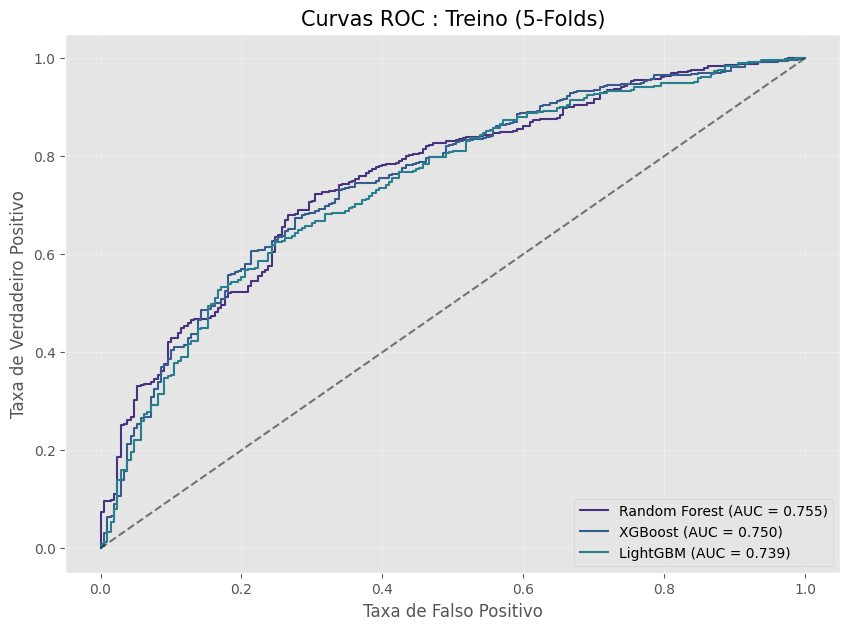

In [ ]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Obtendo as probabilidades via cross-validation para o treino
    y_probas_train = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_probas_train)
    auc_val = roc_auc_score(y_train, y_probas_train)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Curvas ROC : Treino (5-Folds)', fontsize=15)
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### Curvas ROC Teste

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:21:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


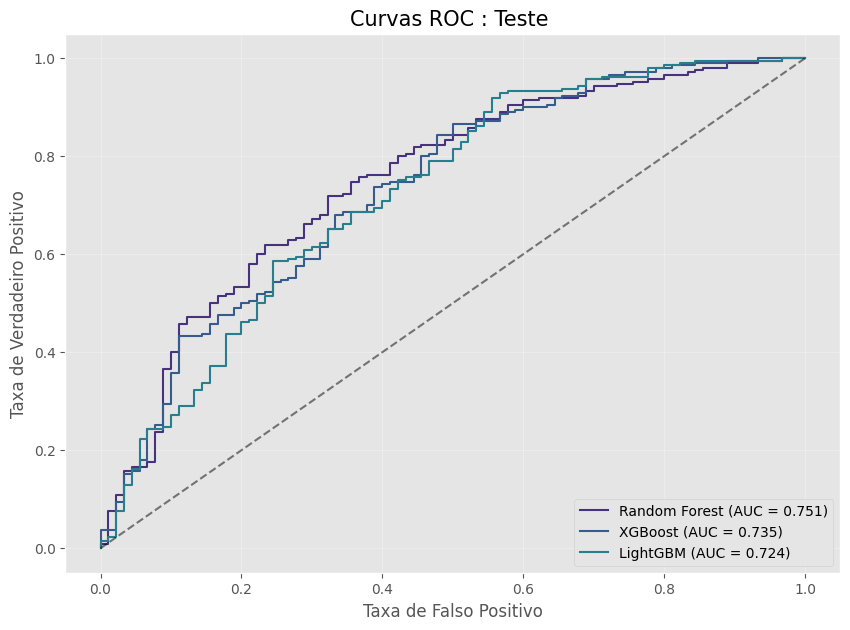

In [ ]:
plt.figure(figsize=(10, 7))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_probas_test = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probas_test)
    auc_val = roc_auc_score(y_test, y_probas_test)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Curvas ROC : Teste ', fontsize=15)
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

### 7.3 Curvas de Aprendizado

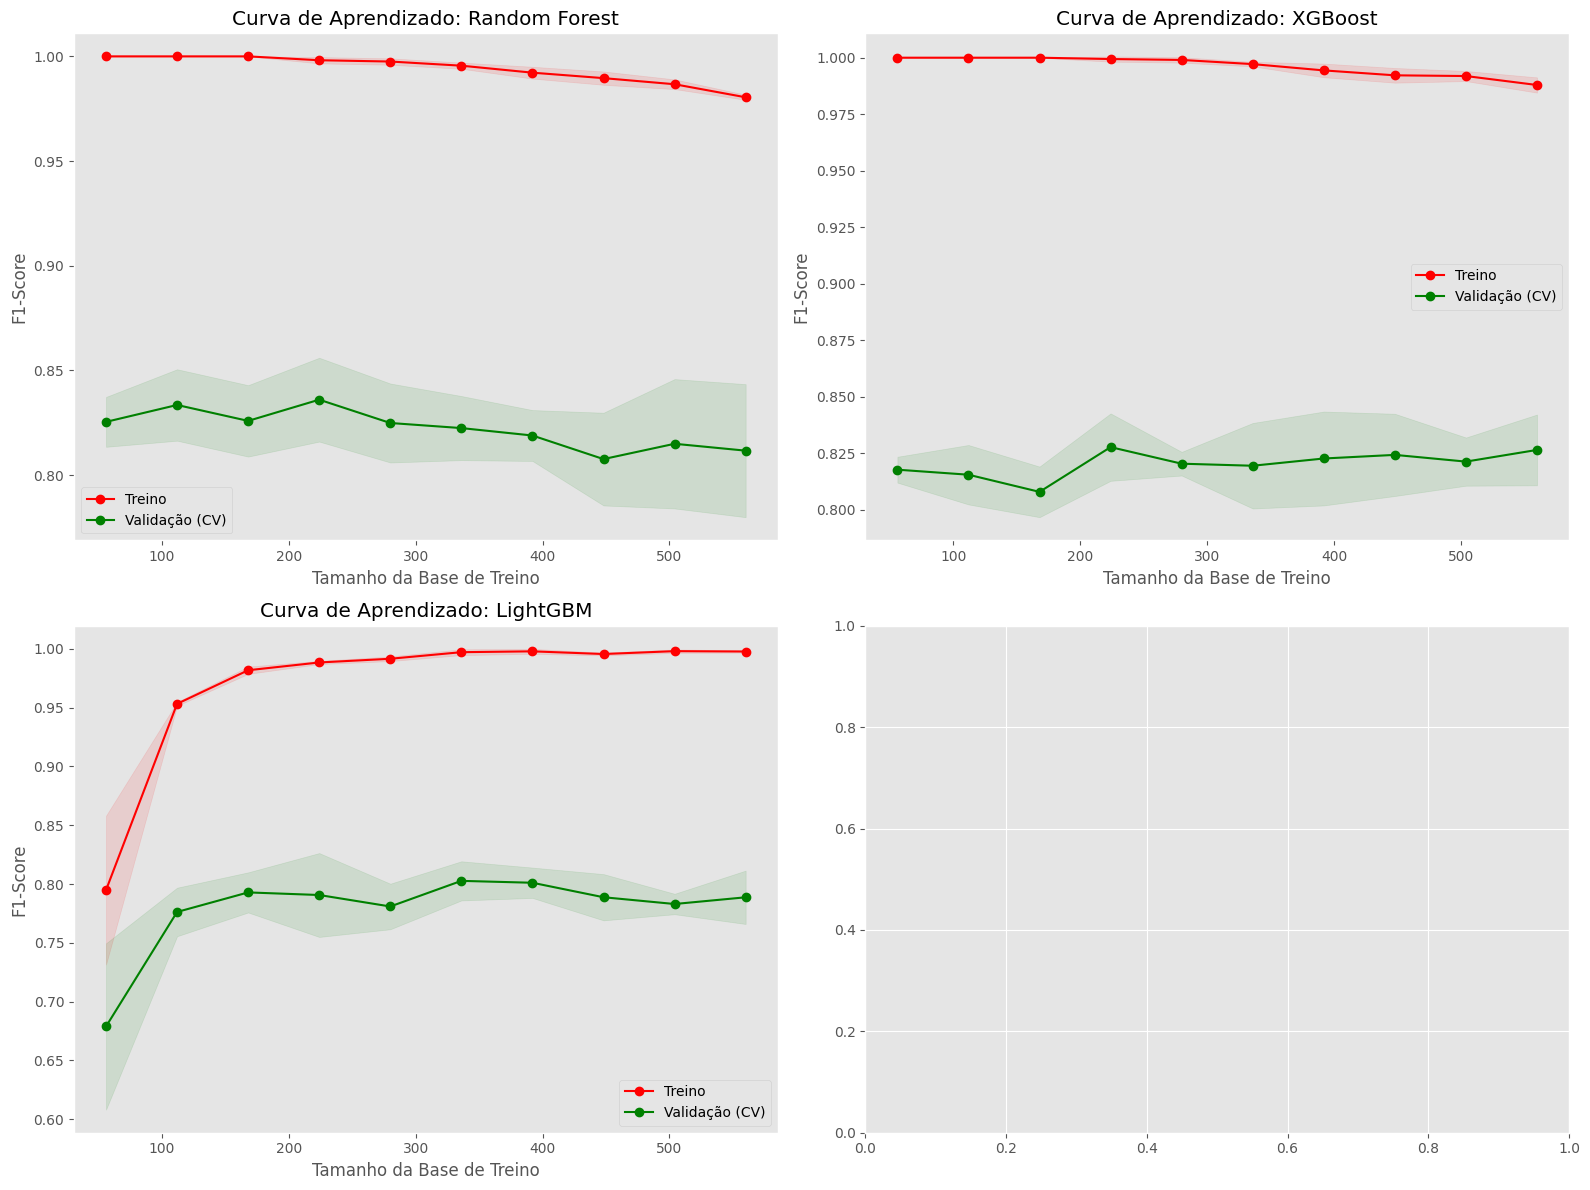

In [ ]:

def plot_learning_curves(models, X, y):
    n_models = len(models)
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
    axes = axes.flatten()

    for i, (name, model) in enumerate(models.items()):
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=5, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='f1'
        )

        # Médias e desvios padrão
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        # Plotagem
        axes[i].plot(train_sizes, train_mean, 'o-', color="r", label="Treino")
        axes[i].plot(train_sizes, test_mean, 'o-', color="g", label="Validação (CV)")
        axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        axes[i].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        axes[i].set_title(f'Curva de Aprendizado: {name}')
        axes[i].set_xlabel('Tamanho da Base de Treino')
        axes[i].set_ylabel('F1-Score')
        axes[i].legend(loc="best")
        axes[i].grid(False)

    plt.tight_layout()
    plt.show()

# Execução
plot_learning_curves(models, X_train, y_train)

### 7.4 Matrizes de Confusão

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:22:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:22:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:22:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:22:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:22:24] WARNING: /w

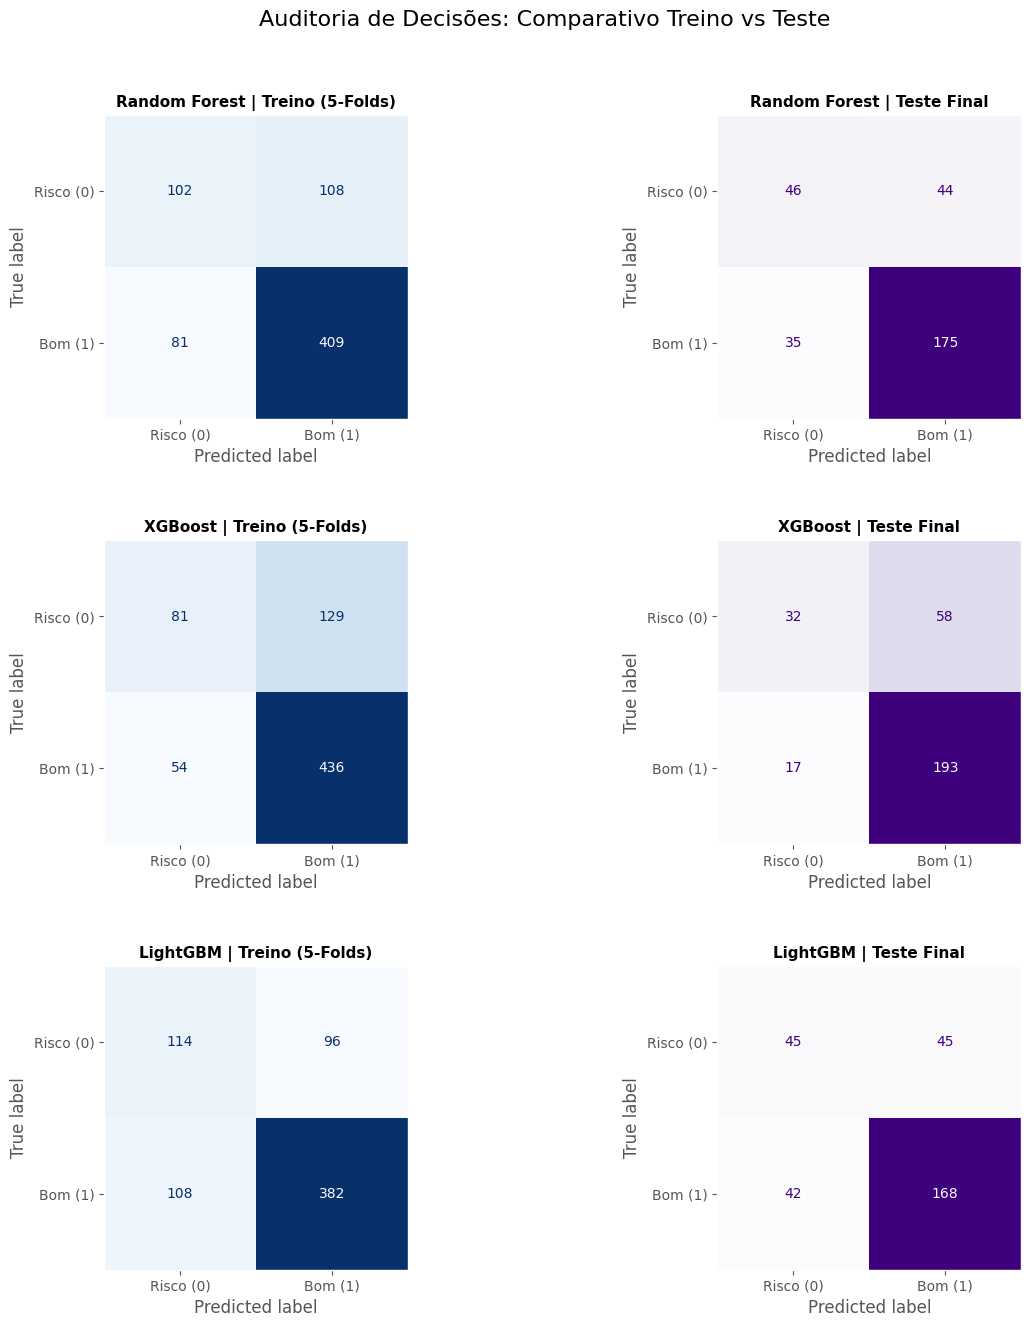

In [ ]:
# Configuração da figura (uma linha por modelo)
n_models = len(models)
fig, axes = plt.subplots(nrows=n_models, ncols=2, figsize=(14, 5 * n_models))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, (name, model) in enumerate(models.items()):

    # 1. Matriz de Treino (Cross-Validation)
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=5)
    ConfusionMatrixDisplay.from_predictions(
        y_train, y_pred_cv, ax=axes[i, 0], cmap='Blues',
        display_labels=['Risco (0)', 'Bom (1)'], colorbar=False
    )
    axes[i, 0].set_title(f'{name} | Treino (5-Folds)', fontsize=11, fontweight='bold')
    axes[i, 0].grid(False)

    # 2. Matriz de Teste
    y_pred_test = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_test, ax=axes[i, 1], cmap='Purples',
        display_labels=['Risco (0)', 'Bom (1)'], colorbar=False
    )
    axes[i, 1].set_title(f'{name} | Teste Final', fontsize=11, fontweight='bold')
    axes[i, 1].grid(False)

plt.suptitle('Auditoria de Decisões: Comparativo Treino vs Teste', fontsize=16, y=0.95)
plt.show()